In this notebook we'll be incorporating the dwell-related process data from Notebook 1 (bus_breaks.csv, breaks_with_routes.csv, and dwell_vs_vehicles.csv) alongside ridership-related exports from Notebook 2 (avg_ridership.csv, filtered_counts.csv, and ridership_full.csv). 

We'll merge them both together by shared route identifiers to align average dwell duration with ridership activity. Through this, we can explore correlations and visual relationships between dwell time and ridership density to investigate whether longer dwell durations stem from high passenger turnover, or if extended dwell times limit overall routes throughout.

Let's start with basic library imports and loading in our datasets.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
bus_breaks = pd.read_csv("../rutgers_bus_data/bus_breaks.csv")
stops = pd.read_csv("../rutgers_bus_data/stops.csv")
ridership = pd.read_csv("../rutgers_bus_data/ridership.csv")
routes = pd.read_csv("../rutgers_bus_data/routes.csv")
vehicles = pd.read_csv("../rutgers_bus_data/vehicles.csv")

breaks_with_routes = pd.read_csv("../processed_data/breaks_with_routes.csv")
dwell_vs_vehicles = pd.read_csv("../processed_data/dwell_vs_vehicles.csv")
avg_ridership = pd.read_csv("../processed_data/avg_ridership.csv")
filtered_counts = pd.read_csv("../processed_data/filtered_counts.csv")
ridership_full = pd.read_csv("../processed_data/ridership_full.csv")

Let's first verify that route identifiers like routeID and routeName are shared between dwell and ridership datasets. Afterwards, we can merge avg_ridership with dwell_vs_vehicles and begin filtering the merged data using filtered_counts to keep only well-represented route-period combinations. With that, we can begin visualizing correlations.

In [63]:
dwell_vs_vehicles = dwell_vs_vehicles.merge(
    vehicles[["routeId", "routeName"]].drop_duplicates(),
    on="routeName",
    how="left"
)

In [64]:
dwell_vs_vehicles.head()

,routeName,avg_dwell_duration,vehicle_count,routeId
0,A Route,67.003533,5,54540
1,B Route,89.480131,8,54541
2,B/L Loop,105.293931,2,59451
3,C Route,27.250858,1,55366
4,Campus Connect Express,66.843426,1,4088


At this point, we've joined vehicles.csv to dwell_vs_vehicles to attach each route's routeId, since future merges will also depend on routeId as the shared key, rather than routeName.

Next, let's merge avg_ridership with dwell_vs_vehicles using routeId to create a unified dataset with both ridership intensity and average dwell durations along each route. We'll drop routeName from dwell_vs_vehicles to prevent overlap.

In [65]:
dwell_vs_vehicles = dwell_vs_vehicles.drop(columns=["routeName"], errors="ignore")

dwell_ridership = avg_ridership.merge(
    dwell_vs_vehicles,
    on="routeId",
    how="inner"
)

In [66]:
dwell_ridership.head()

,routeId,time_period,ridership_count,routeName,avg_dwell_duration,vehicle_count
0,54543.0,Evening,14.066667,EE Route,65.006377,7
1,54543.0,Late Night,10.489796,EE Route,65.006377,7
2,54543.0,Midday,11.800000,EE Route,65.006377,7
3,54543.0,Morning,16.333333,EE Route,65.006377,7
4,54543.0,Rush Hour,3.050000,EE Route,65.006377,7


dwell_ridership contains ridership intensity and operational dwell behavior under each route and time period. We can now examine how average dwell durations correspond to ridership volumes/congestion patterns throughout the day.

Before that, let's first filter out route-time combinations with limited data coverage by merging with filtered_counts to ensure each combination meets the minimum threshold of 20 samples per route-period.

In [67]:
dwell_ridership_filtered = dwell_ridership.merge(
    filtered_counts[["routeName", "time_period"]],
    on=["routeName", "time_period"],
    how="inner"
)

In [68]:
dwell_ridership_filtered.head()

,routeId,time_period,ridership_count,routeName,avg_dwell_duration,vehicle_count
0,54543.0,Evening,14.066667,EE Route,65.006377,7
1,54543.0,Late Night,10.489796,EE Route,65.006377,7
2,54543.0,Morning,16.333333,EE Route,65.006377,7
3,54543.0,Rush Hour,3.050000,EE Route,65.006377,7
4,54545.0,Late Night,15.179487,LX Route,95.269289,9


The resulting dataframe contains:
* Average dwell durations (avg_dwell_duration)
* Corresponding ridership activity (ridership_count)
* Associated route identifiers (routeId, routeName)
* Time-of-day segmentation (time_period)
* Size of vehicle fleets associated with each route-period (vehicle_count)

With this, we're able to move on to visualizing relations between dwell duration and ridership intensity across routes and times of day. Let's start with seeing how well dwell duration, ridership count, and vehicle count relate to one another using both Pearson and Spearman correlation techniques.

Text(0.5, 1.0, 'Pearson Correlation Heatmap: Dwell Duration vs. Ridership & Fleet Size')

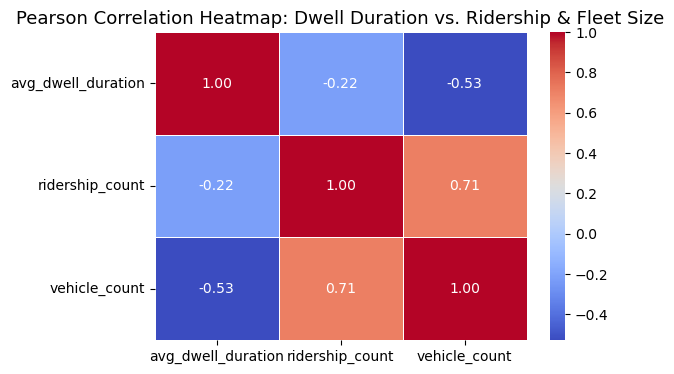

In [69]:
corr_df = dwell_ridership_filtered[["avg_dwell_duration", "ridership_count", "vehicle_count"]]

pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

plt.figure(figsize=(6,4))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap: Dwell Duration vs. Ridership & Fleet Size", fontsize=13)

The heatmap shows a weak negative correlation between ridership and dwell duration, meaning a higher ridership corresponds to slightly shorter dwell times. Similarly, ridership and vehicle count show a strong positive correlation, indicating that busier routes likely receive more vehicles to meet that demand. There's a moderate negative correlation between dwell duration and vehicle count, suggesting that routes with more buses tend to experience quicker rides. 

The combination of these relationships imply that increased vehicles towards a route helps offset the potential dwell-time impacts of high ridership. It shows how Rutgers buses do relatively well to manage passenger flow by scaling the allocation of their buses based on route demand. 

Let's look at dwell times versus ridership seperated by time periods to see if there's any parts of the day that exhibit stronger or weaker relationships between ridership intensity and stop duration.

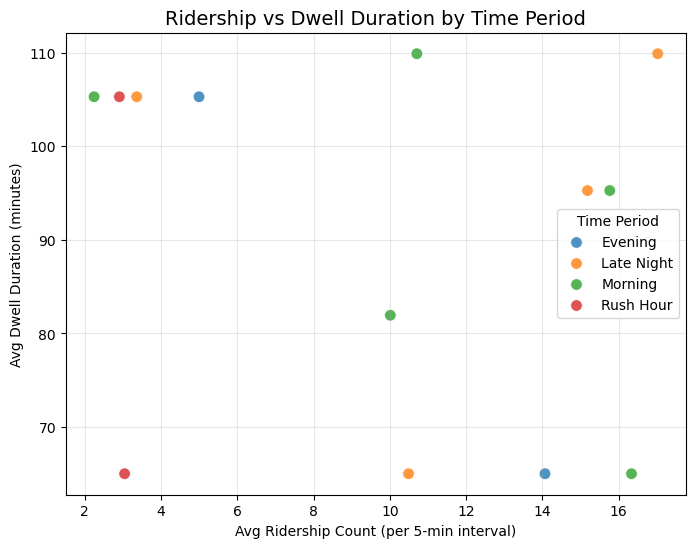

In [70]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=dwell_ridership_filtered, x="ridership_count", y="avg_dwell_duration", hue="time_period", alpha=0.8, s=70)

plt.title("Ridership vs Dwell Duration by Time Period", fontsize=14)
plt.xlabel("Avg Ridership Count (per 5-min interval)")
plt.ylabel("Avg Dwell Duration (minutes)")
plt.legend(title="Time Period")
plt.grid(alpha=0.3)

We see that most routes have a moderate ridership of around 5-15 people per 5-minute interval and moderate dwell durations of 65-110 minutes. There isn't exactly a linear relationship, but some routes with relatively low ridership tend to exhibit long dwell times, possibly due to frequency of vehicles, boarding delays, or congestion in busy areas.

Let's dive a bit deeper into time of day and how that impacts ridership/dwell numbers.

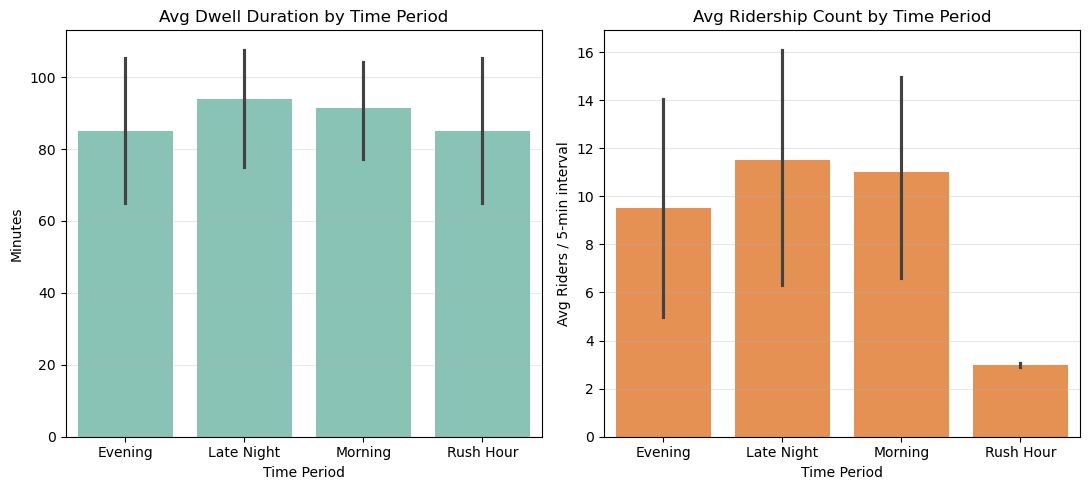

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(11,5), sharey=False)

sns.barplot(data=dwell_ridership_filtered, x="time_period", y="avg_dwell_duration", ax=axes[0], color="#7fcdbb")
axes[0].set_title("Avg Dwell Duration by Time Period")
axes[0].set_xlabel("Time Period")
axes[0].set_ylabel("Minutes")
axes[0].grid(axis="y", alpha=0.3)

sns.barplot(data=dwell_ridership_filtered, x="time_period", y="ridership_count", ax=axes[1], color="#fd8d3c")
axes[1].set_title("Avg Ridership Count by Time Period")
axes[1].set_xlabel("Time Period")
axes[1].set_ylabel("Avg Riders / 5-min interval")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()

We really don't see much variation within the current bar charts due to them displaying aggregated averages that flatten out the potential variation across stops/routes/specific hours. The Rush Hour period might include on-campus loops like the C route as well as routes like B and LX that drastically differ in ridership/dwell patterns.

Let's group our data at the route level next.

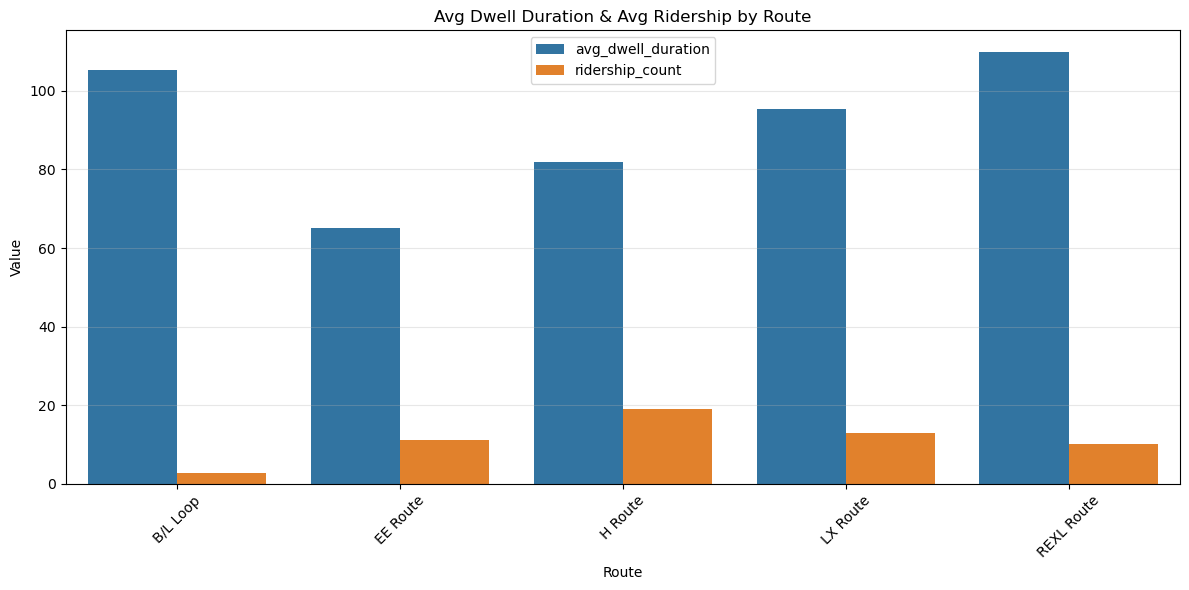

In [72]:
route_summary = dwell_ridership.groupby("routeName", as_index=False).agg({"avg_dwell_duration": "mean", "ridership_count": "mean", "vehicle_count": "mean"})

route_melted = route_summary.melt(id_vars=["routeName"], value_vars=["avg_dwell_duration", "ridership_count"], var_name="Metric", value_name="Value")

plt.figure(figsize=(12,6))
sns.barplot(data=route_melted, x="routeName",  y="Value", hue="Metric")
plt.title("Avg Dwell Duration & Avg Ridership by Route")
plt.xlabel("Route")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="")
plt.tight_layout()

We see that REXL and B/L Loop exhibit the longest average dwell durations, even though B/L Loop handles the lowest ridership among the routes. Routes like H and LX follow in terms of dwell time, but experience much more ridership compared to REXL and B/L. This suggests that the H Route likely benefits from a well-balanced vehicle allocation that accommodates its passenger load, maintaining efficiency despite demand. Meanwhile, REXL may face insufficient vehicle coverage relative to its ridership, making it the route with the highest average dwell duration.

### Final Takeaways

Dwell duration, ridership volume, and allocation of vehicles towards each route each have strong influence over how efficient each bus route performs operationally at Rutgers.
* Routes like REXL and B/L Loop show the highest dwell durations but don't necessarilly have higher ridership. In contrast, H and LX routes manage higher ridership loads with relatively shorter dwell times, indicating better vehicle allocation or route design efficiency.
* Vehicle count plays a key role in mitigating dwell time. Routes with fewer assigned vehicles (ex: REXL) exhibit longer dwell durations, suggesting potential scheduling inefficiencies or inadequate fleet size relative to passenger demand.
* The H Route managed higher passenger volumes with shorter dwell times, showing the impact of effective vehicle distribution.
* Most dwell time occured near Student Centers (ex: Busch & Livingston), highlighting them as primary points of congestion.

Overall, Rutgers could improve schedule adherence & reduce wait times by redistributing vehicles more closely based on ridership and dwell metrics.